In [ ]:
# ARMA

In [ ]:
# Autoregressive Moving Average Model

In [ ]:
# import Libraries
import inspect
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from pymongo import MongoClient
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

In [ ]:
# connect to MongoDB
client = MongoClient("mongodb://127.0.0.1:27017")
# Assign database
db = client["air-quality"]
# Assign collection
nairobi = db["nairobi"]

In [ ]:
# Wrangle Function
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(list(results))
    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    # Set as index
    df = df.set_index("timestamp")
    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # Localize timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")

    # Remove outliers
    df = df[df["P2"] < 500]

    # Resample and forward-fill
    y = df.resample("1H").mean().ffill()

    return y

In [ ]:
# call wrangle function
y = wrangle(nairobi)
print(y.shape)
y.head()

(2928, 1)


,P2
timestamp,
2018-09-01 03:00:00+03:00,17.541667
2018-09-01 04:00:00+03:00,15.800000
2018-09-01 05:00:00+03:00,11.420000
2018-09-01 06:00:00+03:00,11.614167
2018-09-01 07:00:00+03:00,17.665000


In [ ]:
# Wrangle Function
def wrangle(collection, resample_rule="h"):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(list(results))
    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    # Set as index
    df = df.set_index("timestamp")
    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # Localize timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")

    # Remove outliers
    df = df[df["P2"] < 500]

    # Resample and forward-fill
    y = df.resample(resample_rule).mean().ffill()

    return y
# call wrangle function
y = wrangle(nairobi)
print(y.shape)
y.head()

(2928, 1)


,P2
timestamp,
2018-09-01 03:00:00+03:00,17.541667
2018-09-01 04:00:00+03:00,15.800000
2018-09-01 05:00:00+03:00,11.420000
2018-09-01 06:00:00+03:00,11.614167
2018-09-01 07:00:00+03:00,17.665000


In [ ]:
# call wrangle function
y = wrangle(nairobi, resample_rule="d")
print(y.shape)
y.head()

(123, 1)


,P2
timestamp,
2018-09-01 00:00:00+03:00,17.958016
2018-09-02 00:00:00+03:00,11.181303
2018-09-03 00:00:00+03:00,10.877972
2018-09-04 00:00:00+03:00,12.968958
2018-09-05 00:00:00+03:00,9.114634


Text(0, 0.5, 'Correlation Coefficient')

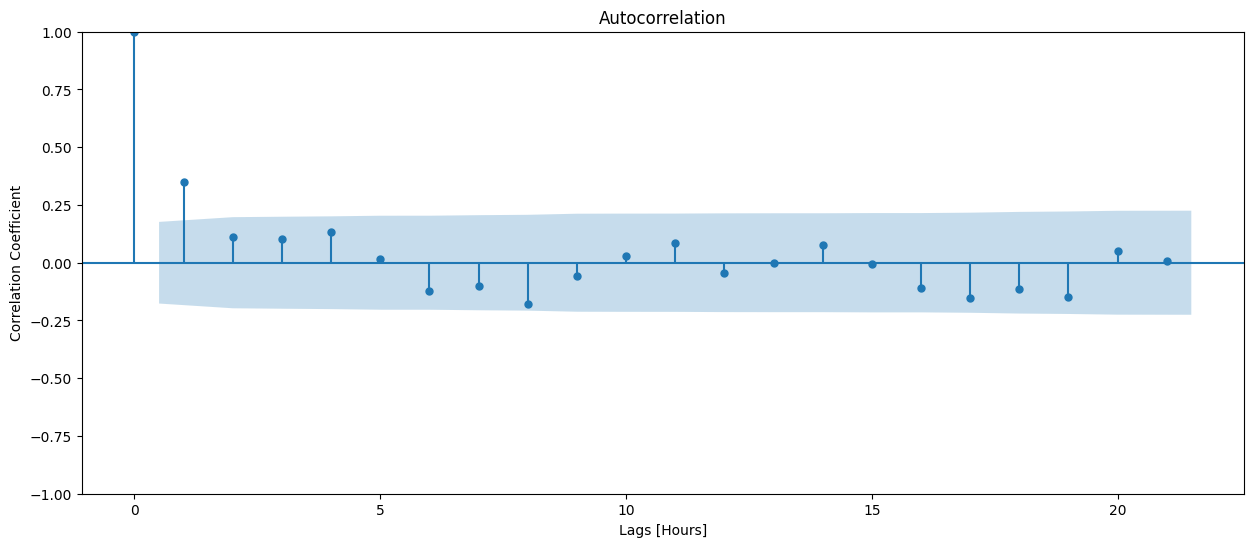

In [ ]:
# exploratory Data Analysis
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y, ax=ax)
plt.xlabel("Lags [Hours]")
plt.ylabel("Correlation Coefficient")

In [ ]:
# call wrangle function
y = wrangle(nairobi)
print(y.shape)
y.head()

(2928, 1)


,P2
timestamp,
2018-09-01 03:00:00+03:00,17.541667
2018-09-01 04:00:00+03:00,15.800000
2018-09-01 05:00:00+03:00,11.420000
2018-09-01 06:00:00+03:00,11.614167
2018-09-01 07:00:00+03:00,17.665000


Text(0, 0.5, 'Correlation Coefficient')

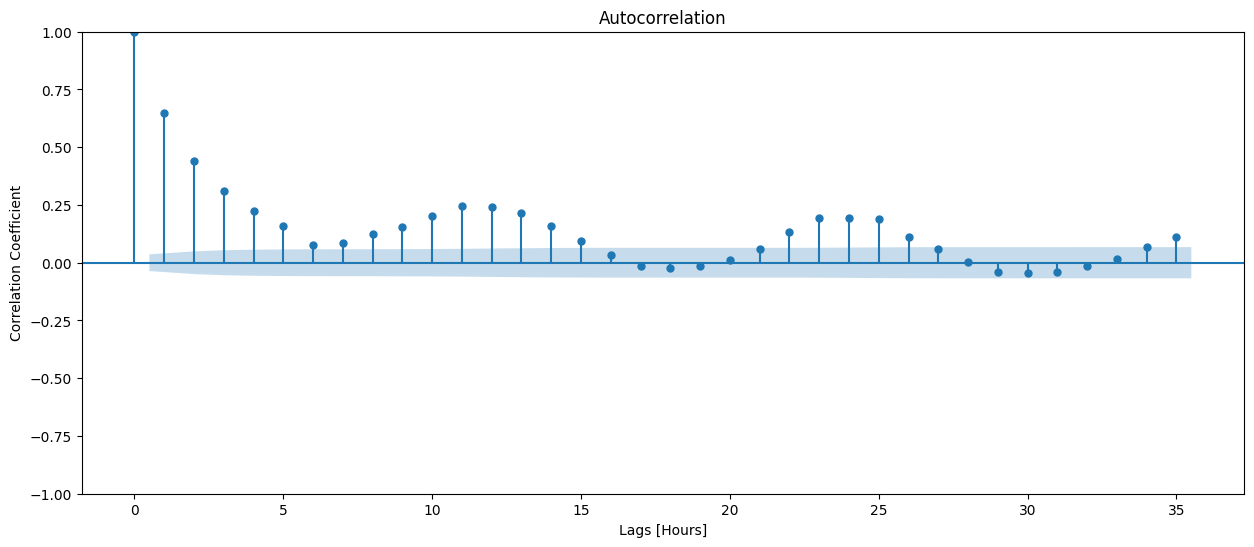

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y, ax=ax)
plt.xlabel("Lags [Hours]")
plt.ylabel("Correlation Coefficient")

Text(0, 0.5, 'Correlation Coefficient')

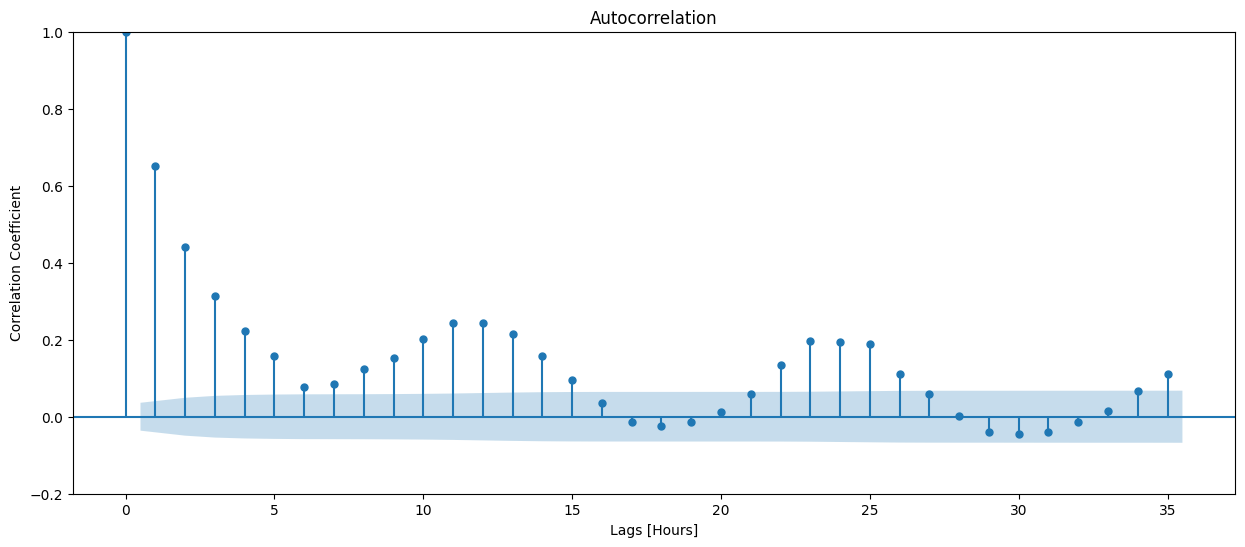

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y, ax=ax)
ax.set_ylim(bottom= -0.2)
plt.xlabel("Lags [Hours]")
plt.ylabel("Correlation Coefficient")

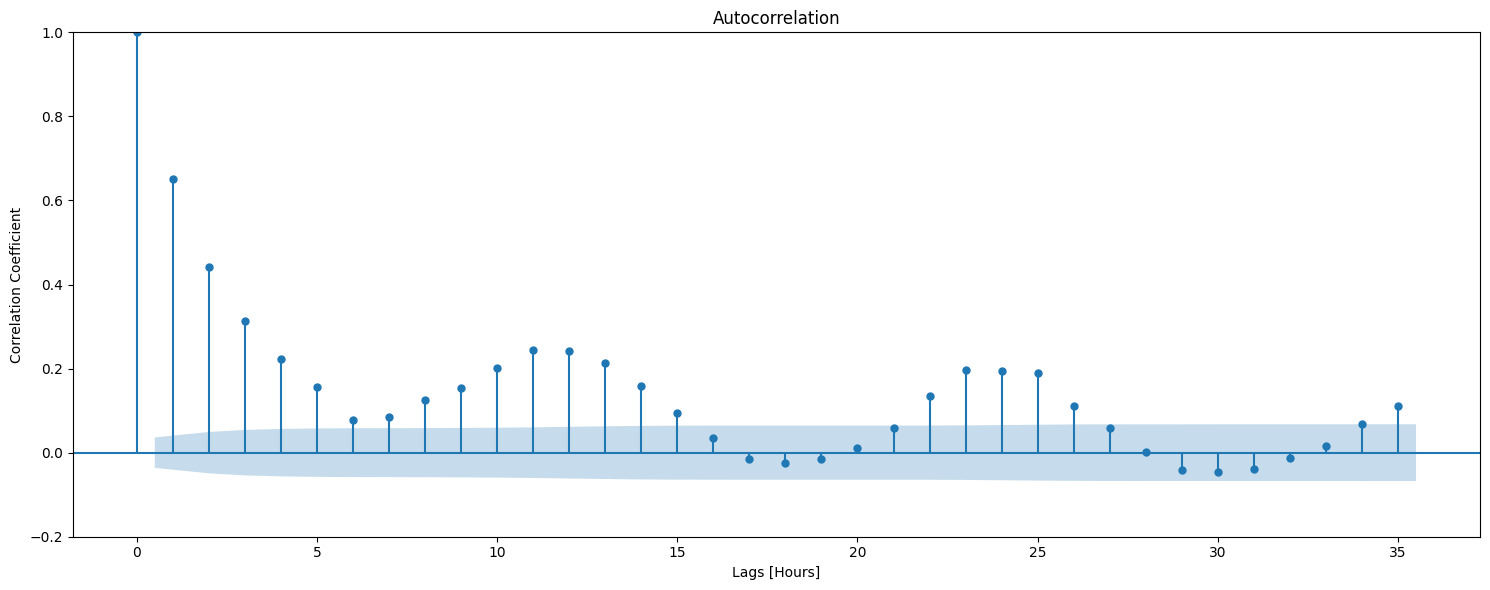

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y, ax=ax)
ax.set_ylim(bottom= -0.2)
plt.xlabel("Lags [Hours]")
plt.ylabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

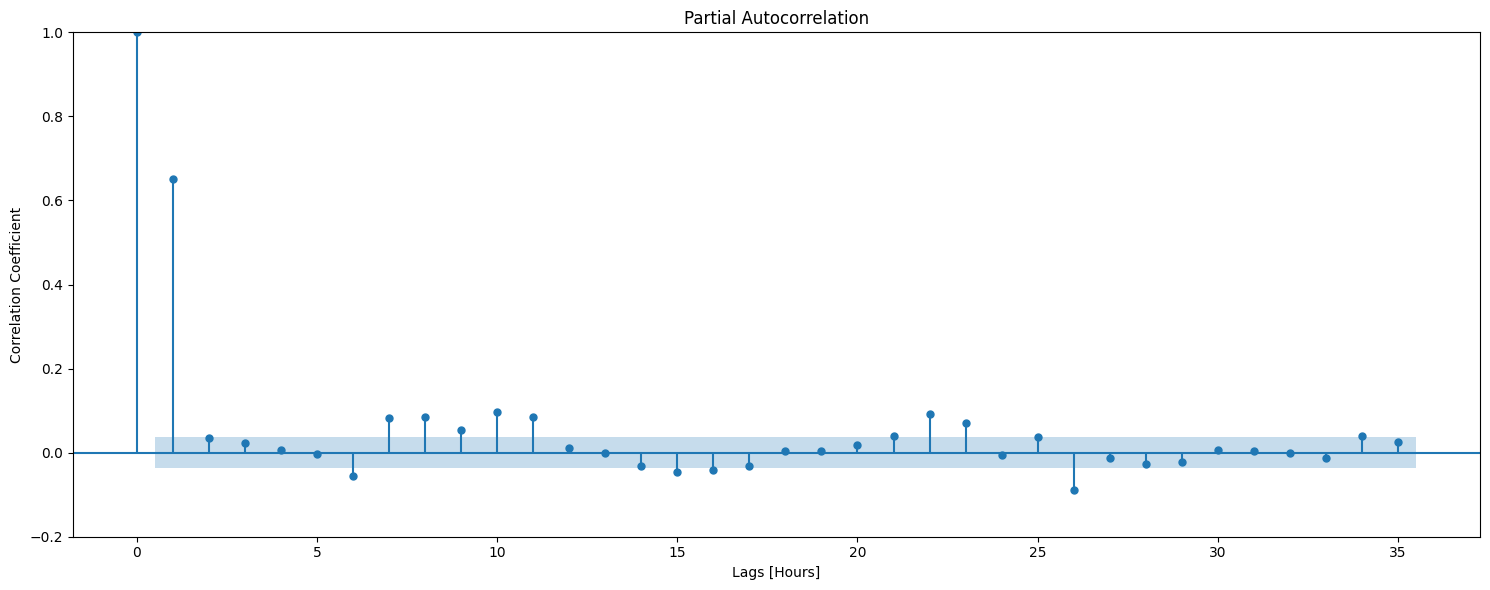

In [ ]:
# Partial Autocorrelation Plot
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(y, ax=ax)
ax.set_ylim(bottom= -0.2)
plt.xlabel("Lags [Hours]")
plt.ylabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

In [ ]:
# call wrangle function
y = wrangle(nairobi)
print(y.shape)
y.tail()

(2928, 1)


,P2
timestamp,
2018-12-31 22:00:00+03:00,7.060833
2018-12-31 23:00:00+03:00,7.854167
2019-01-01 00:00:00+03:00,9.755833
2019-01-01 01:00:00+03:00,12.665000
2019-01-01 02:00:00+03:00,18.803333


In [ ]:
# Train-Test Split
# Training set: all readings from October 2018
y_train = y['2018-10-01':'2018-10-31']

# Test set: readings from 1 November 2018
y_test = y['2018-11-01':'2018-11-01']

In [ ]:
print(y_train.shape)
y_train.head()

(744, 1)


,P2
timestamp,
2018-10-01 00:00:00+03:00,7.030000
2018-10-01 01:00:00+03:00,6.559167
2018-10-01 02:00:00+03:00,6.692500
2018-10-01 03:00:00+03:00,8.011667
2018-10-01 04:00:00+03:00,8.885833


In [ ]:
print(y_test.shape)
y_test.head()

(24, 1)


,P2
timestamp,
2018-11-01 00:00:00+03:00,5.556364
2018-11-01 01:00:00+03:00,5.664167
2018-11-01 02:00:00+03:00,5.835000
2018-11-01 03:00:00+03:00,7.992500
2018-11-01 04:00:00+03:00,6.785000


In [ ]:
# Baseline
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)
print("Mean P2 Reading:", round(y_train_mean[0], 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 10.12
Baseline MAE: 4.17


In [ ]:
p_params = range(0, 25, 8)
q_params = range(0, 3, 1)

In [ ]:
list(p_params)

[0, 8, 16, 24]

In [ ]:
list(q_params)

[0, 1, 2]

In [ ]:
for p in p_params:
    for q in q_params:
        order = (p, 0, q)
        print(order)

(0, 0, 0)
(0, 0, 1)
(0, 0, 2)
(8, 0, 0)
(8, 0, 1)
(8, 0, 2)
(16, 0, 0)
(16, 0, 1)
(16, 0, 2)
(24, 0, 0)
(24, 0, 1)
(24, 0, 2)


In [ ]:
for p in p_params:
    for q in q_params:
        order = (p, 0, q)
        print(order)
        model = ARIMA(y_train, order=order).fit()
        print(f"Trained ARMA {order}")

(0, 0, 0)
Trained ARMA (0, 0, 0)
(0, 0, 1)
Trained ARMA (0, 0, 1)
(0, 0, 2)
Trained ARMA (0, 0, 2)
(8, 0, 0)
Trained ARMA (8, 0, 0)
(8, 0, 1)
Trained ARMA (8, 0, 1)
(8, 0, 2)
Trained ARMA (8, 0, 2)
(16, 0, 0)
Trained ARMA (16, 0, 0)
(16, 0, 1)
Trained ARMA (16, 0, 1)
(16, 0, 2)
Trained ARMA (16, 0, 2)
(24, 0, 0)
Trained ARMA (24, 0, 0)
(24, 0, 1)
Trained ARMA (24, 0, 1)
(24, 0, 2)
Trained ARMA (24, 0, 2)


In [ ]:
# Add timing
for p in p_params:
    for q in q_params:
        order = (p, 0, q)
        start_time = time.time()
        print(order)
        model = ARIMA(y_train, order=order).fit()
        elapsed_time = round(time.time() - start_time, 2)
        
        print(f"Trained ARMA {order} in {elapsed_time} seconds.")

(0, 0, 0)
Trained ARMA (0, 0, 0) in 0.12 seconds.
(0, 0, 1)
Trained ARMA (0, 0, 1) in 0.07 seconds.
(0, 0, 2)
Trained ARMA (0, 0, 2) in 0.12 seconds.
(8, 0, 0)
Trained ARMA (8, 0, 0) in 0.4 seconds.
(8, 0, 1)
Trained ARMA (8, 0, 1) in 1.83 seconds.
(8, 0, 2)
Trained ARMA (8, 0, 2) in 4.99 seconds.
(16, 0, 0)
Trained ARMA (16, 0, 0) in 2.08 seconds.
(16, 0, 1)
Trained ARMA (16, 0, 1) in 6.05 seconds.
(16, 0, 2)
Trained ARMA (16, 0, 2) in 11.23 seconds.
(24, 0, 0)
Trained ARMA (24, 0, 0) in 9.72 seconds.
(24, 0, 1)
Trained ARMA (24, 0, 1) in 11.03 seconds.
(24, 0, 2)
Trained ARMA (24, 0, 2) in 17.28 seconds.


In [ ]:
for p in p_params:
    for q in q_params:
        order = (p, 0, q)
        start_time = time.time()
        print(order)
        model = ARIMA(y_train, order=order).fit()
        elapsed_time = round(time.time() - start_time, 2)
        
        print(f"Trained ARMA {order} in {elapsed_time} seconds.")
        # Generate in-sample (training) predictions
        y_pred = model.predict() 
        # Calculate training MAE
        mae = mean_absolute_error(y_train, y_pred)
        print(f"Training MAE: {round(mae, 2)}")

(0, 0, 0)
Trained ARMA (0, 0, 0) in 0.22 seconds.
Training MAE: 4.17
(0, 0, 1)
Trained ARMA (0, 0, 1) in 0.07 seconds.
Training MAE: 3.35
(0, 0, 2)
Trained ARMA (0, 0, 2) in 0.19 seconds.
Training MAE: 3.11
(8, 0, 0)
Trained ARMA (8, 0, 0) in 0.33 seconds.
Training MAE: 2.94
(8, 0, 1)
Trained ARMA (8, 0, 1) in 1.15 seconds.
Training MAE: 2.91
(8, 0, 2)
Trained ARMA (8, 0, 2) in 3.71 seconds.
Training MAE: 2.91
(16, 0, 0)
Trained ARMA (16, 0, 0) in 2.24 seconds.
Training MAE: 2.92
(16, 0, 1)
Trained ARMA (16, 0, 1) in 6.41 seconds.
Training MAE: 2.93
(16, 0, 2)
Trained ARMA (16, 0, 2) in 9.42 seconds.
Training MAE: 2.91
(24, 0, 0)
Trained ARMA (24, 0, 0) in 8.25 seconds.
Training MAE: 2.91
(24, 0, 1)
Trained ARMA (24, 0, 1) in 11.32 seconds.
Training MAE: 2.91
(24, 0, 2)
Trained ARMA (24, 0, 2) in 25.53 seconds.
Training MAE: 2.9


In [ ]:
# Grid to store MAEs
# Create dictionary to store MAEs
mae_grid = dict()
# Outer loop: Iterate through possible values for `p`
for p in p_params:
    # Create key-value pair in dict. Key is `p`, value is empty list.
    mae_grid[p] = list()
    # Inner loop: Iterate through possible values for `q`
    for q in q_params:
        # Combination of hyperparameters for model
        order = (p, 0, q)
        # Note start time
        start_time = time.time()
        # Train model
        model = ARIMA(y_train, order=order).fit()
        # Calculate model training time
        elapsed_time = round(time.time() - start_time, 2)
        print(f"Trained ARIMA {order} in {elapsed_time} seconds.")
        # Generate in-sample (training) predictions
        y_pred = model.predict() 
        # Calculate training MAE
        mae = mean_absolute_error(y_train, y_pred)
        # Append MAE to list in dictionary
        mae_grid[p].append(mae)

print()
print(mae_grid)

Trained ARIMA (0, 0, 0) in 0.12 seconds.
Trained ARIMA (0, 0, 1) in 0.06 seconds.
Trained ARIMA (0, 0, 2) in 0.1 seconds.
Trained ARIMA (8, 0, 0) in 0.38 seconds.
Trained ARIMA (8, 0, 1) in 2.14 seconds.
Trained ARIMA (8, 0, 2) in 4.08 seconds.
Trained ARIMA (16, 0, 0) in 2.01 seconds.
Trained ARIMA (16, 0, 1) in 6.78 seconds.
Trained ARIMA (16, 0, 2) in 10.69 seconds.
Trained ARIMA (24, 0, 0) in 9.81 seconds.
Trained ARIMA (24, 0, 1) in 12.41 seconds.
Trained ARIMA (24, 0, 2) in 28.53 seconds.

{0: [4.171460443827197, 3.350642743347593, 3.1057222591330715], 8: [2.938448056995881, 2.9149014904056427, 2.9054609596111103], 16: [2.920108472701317, 2.9294362670750345, 2.9145209482592604], 24: [2.914390328224091, 2.913601323358812, 2.8979214044126165]}


In [ ]:
mae_grid

{0: [4.171460443827197, 3.350642743347593, 3.1057222591330715],
 8: [2.938448056995881, 2.9149014904056427, 2.9054609596111103],
 16: [2.920108472701317, 2.9294362670750345, 2.9145209482592604],
 24: [2.914390328224091, 2.913601323358812, 2.8979214044126165]}

In [ ]:
# Convert dictionary to DataFrame
mae_df = pd.DataFrame(mae_grid)
mae_df.round(4)

,0,8,16,24
0,4.1715,2.9384,2.9201,2.9144
1,3.3506,2.9149,2.9294,2.9136
2,3.1057,2.9055,2.9145,2.8979


Text(0.5, 1.0, 'Training MAE for different ARMA(p,q) models')

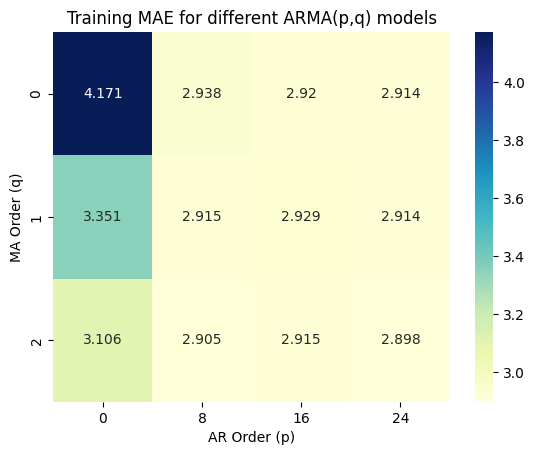

In [ ]:
# heatmap of MAE values
sns.heatmap(mae_df, annot=True, fmt=".4g", cmap="YlGnBu")
plt.xlabel("AR Order (p)")
plt.ylabel("MA Order (q)")
plt.title("Training MAE for different ARMA(p,q) models")

Text(0.5, 1.0, 'ARMA Grid Search (Criterion: MAE)')

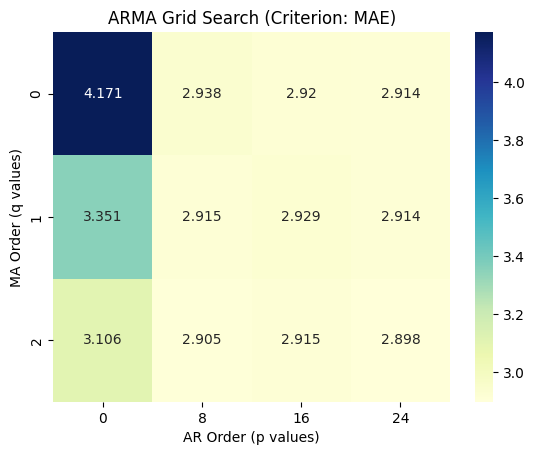

In [ ]:
# heatmap of MAE values
sns.heatmap(mae_df, annot=True, fmt=".4g", cmap="YlGnBu")
plt.xlabel("AR Order (p values)")
plt.ylabel("MA Order (q values)")
plt.title("ARMA Grid Search (Criterion: MAE)")

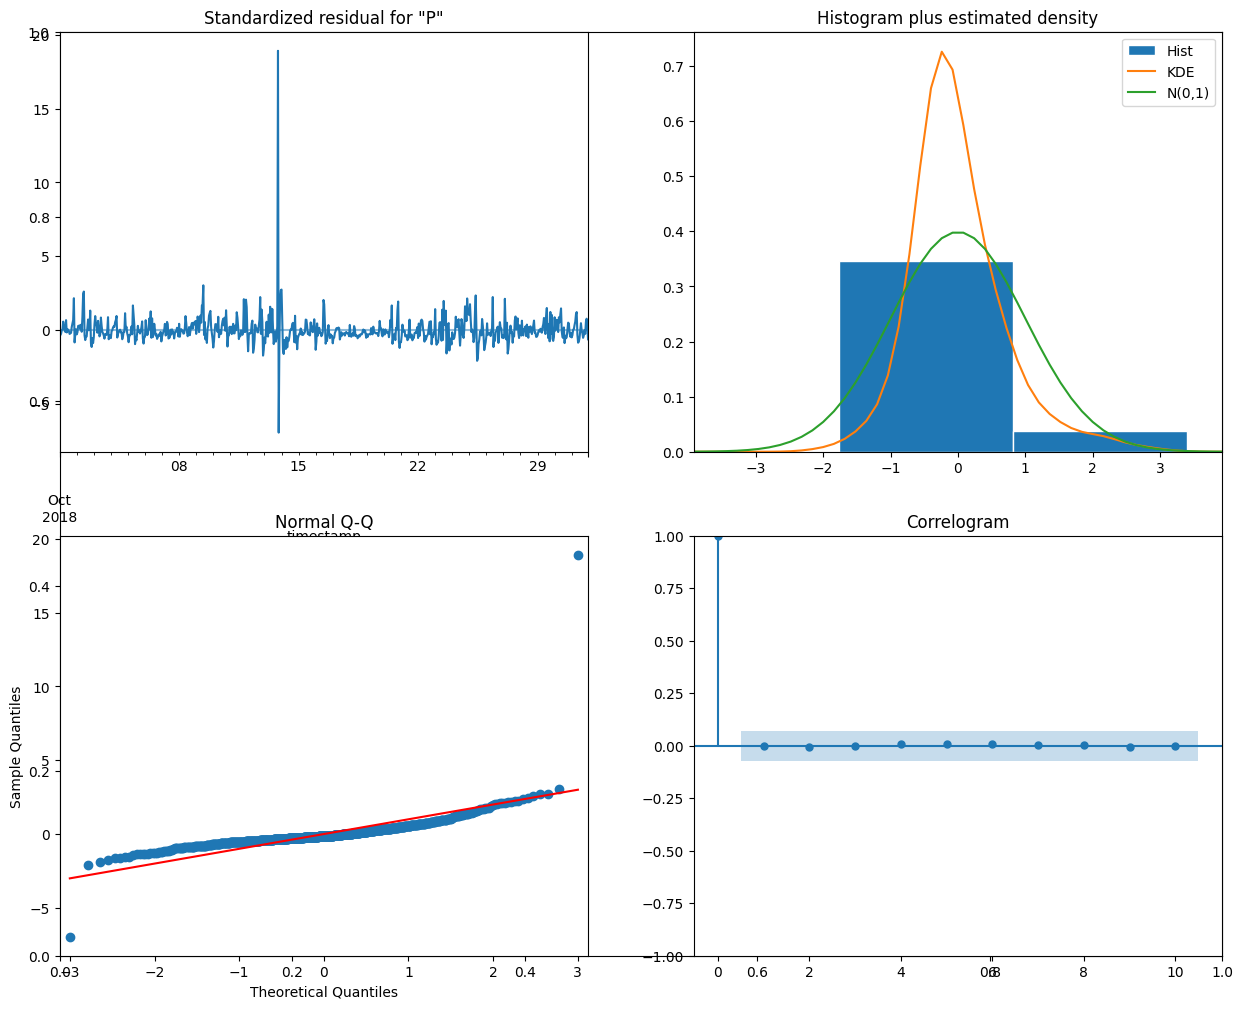

In [ ]:
# Residual Analysis
fig, ax = plt.subplots(figsize=(15, 12))
model.plot_diagnostics(fig=fig);

In [ ]:
# Evaluate
# using the best model (8,0,1) with lowest training time and relatively low MAE
y_pred_wfv = pd.Series(dtype=float)
history = y_train.copy()

for i in range(len(y_test)):

    model = ARIMA(history, order=(8, 0, 1)).fit()
    next_pred = model.forecast()

    # Append prediction
    y_pred_wfv = pd.concat([y_pred_wfv, next_pred])

    # Append the actual next value from y_test
    history = pd.concat([history, y_test.loc[next_pred.index]])

In [ ]:
test_mae = mean_absolute_error(y_test, y_pred_wfv)
print("Test MAE (walk forward validation):", round(test_mae, 2))

Test MAE (walk forward validation): 1.67


In [ ]:
# Make both 1-D
y_test = y_test.squeeze()
y_pred_wfv = y_pred_wfv.squeeze()

# Align indices
y_pred_wfv.index = y_test.index

# Combine
df_predictions = pd.DataFrame({
    "y_test": y_test,
    "y_pred_wfv": y_pred_wfv
})

# Plot
fig = px.line(df_predictions, labels={"value": "PM2.5"})
fig.show()

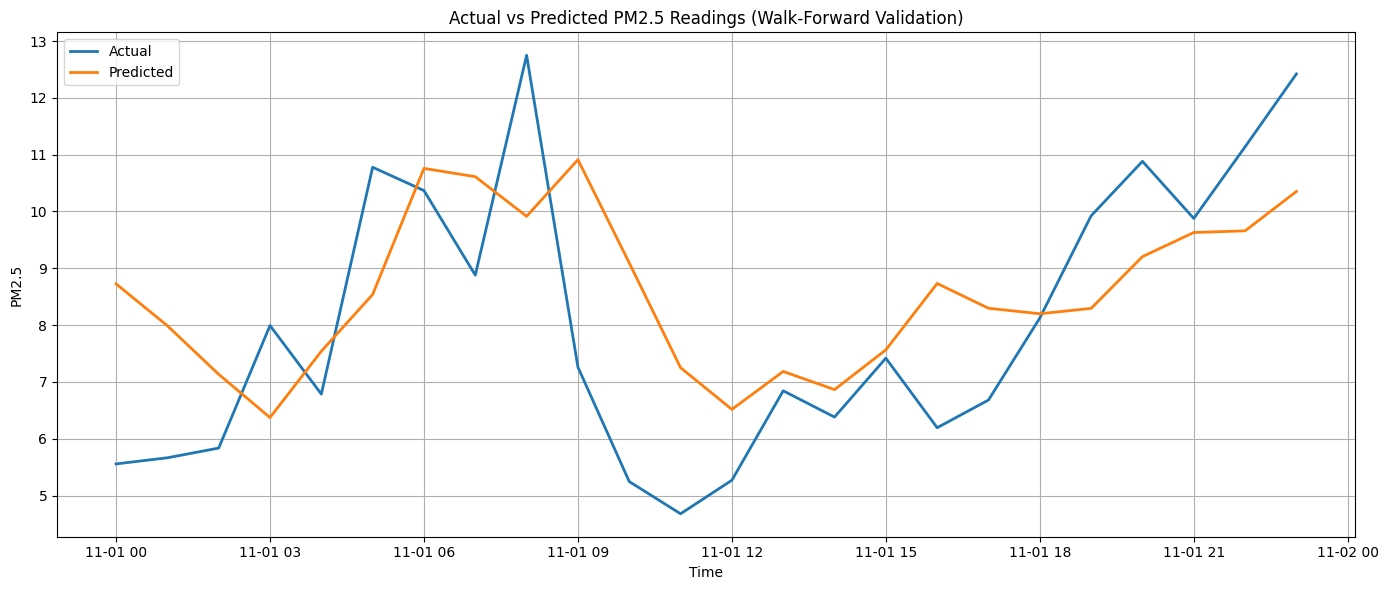

In [ ]:
# Matplotlib Plot for results
# Ensure 1-D series
y_test = y_test.squeeze()
y_pred_wfv = y_pred_wfv.squeeze()

# Align prediction index with test index
y_pred_wfv.index = y_test.index

# Plot
plt.figure(figsize=(14, 6))

plt.plot(y_test.index, y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred_wfv.index, y_pred_wfv.values, label="Predicted", linewidth=2)

plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.title("Actual vs Predicted PM2.5 Readings (Walk-Forward Validation)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()